In [11]:
import matplotlib.pyplot as plt
import numpy as np
from ham import *

ReflectionFromZlZ0(55,50)


In [12]:
ReflectionCoeffToSWR(ZLZ0ToReflection(5))

10.000000000000004

In [13]:
for ZL in [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 51, 52, 53, 54, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
    SWR = ReflectionCoeffToSWR(ZLZ0ToReflection(ZL))
    print(f"ZL: {ZL} Ohms -> SWR: {SWR:.2f}")




ZL: 5 Ohms -> SWR: 10.00
ZL: 10 Ohms -> SWR: 5.00
ZL: 15 Ohms -> SWR: 3.33
ZL: 20 Ohms -> SWR: 2.50
ZL: 25 Ohms -> SWR: 2.00
ZL: 30 Ohms -> SWR: 1.67
ZL: 35 Ohms -> SWR: 1.43
ZL: 40 Ohms -> SWR: 1.25
ZL: 45 Ohms -> SWR: 1.11
ZL: 50 Ohms -> SWR: 1.00
ZL: 51 Ohms -> SWR: 1.02
ZL: 52 Ohms -> SWR: 1.04
ZL: 53 Ohms -> SWR: 1.06
ZL: 54 Ohms -> SWR: 1.08
ZL: 55 Ohms -> SWR: 1.10
ZL: 60 Ohms -> SWR: 1.20
ZL: 65 Ohms -> SWR: 1.30
ZL: 70 Ohms -> SWR: 1.40
ZL: 75 Ohms -> SWR: 1.50
ZL: 80 Ohms -> SWR: 1.60
ZL: 85 Ohms -> SWR: 1.70
ZL: 90 Ohms -> SWR: 1.80
ZL: 95 Ohms -> SWR: 1.90
ZL: 100 Ohms -> SWR: 2.00
ZL: 150 Ohms -> SWR: 3.00
ZL: 200 Ohms -> SWR: 4.00
ZL: 250 Ohms -> SWR: 5.00
ZL: 300 Ohms -> SWR: 6.00
ZL: 350 Ohms -> SWR: 7.00
ZL: 400 Ohms -> SWR: 8.00
ZL: 450 Ohms -> SWR: 9.00
ZL: 500 Ohms -> SWR: 10.00


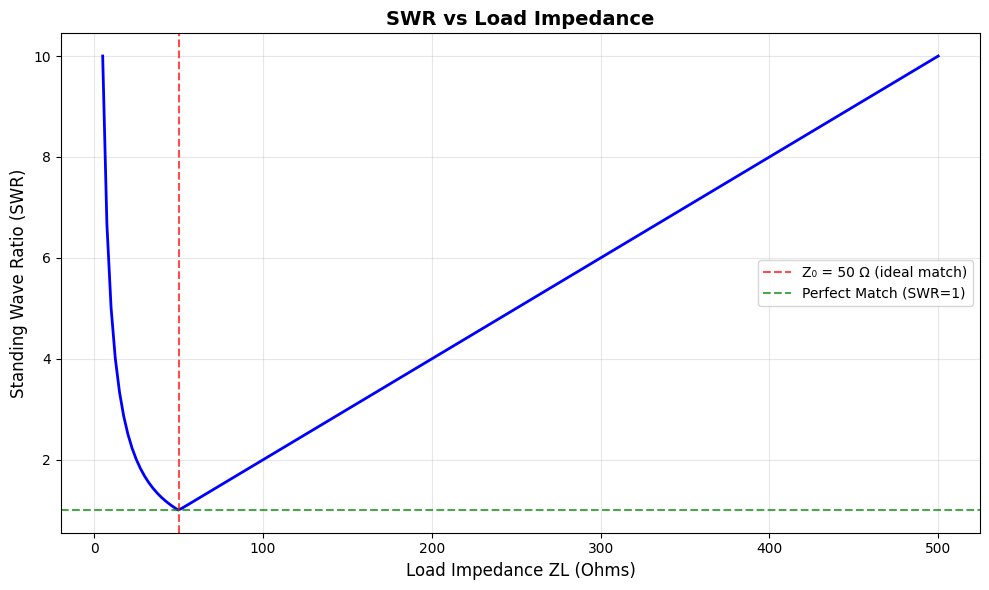

Minimum SWR: 1.0045 at ZL ≈ 50 Ω
Maximum SWR in range: 10.0000


In [14]:
# Generate SWR values across a range of ZL
ZL_values = np.linspace(5, 500, 200)
SWR_values = [ReflectionCoeffToSWR(ZLZ0ToReflection(ZL)) for ZL in ZL_values]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(ZL_values, SWR_values, 'b-', linewidth=2)
plt.xlabel('Load Impedance ZL (Ohms)', fontsize=12)
plt.ylabel('Standing Wave Ratio (SWR)', fontsize=12)
plt.title('SWR vs Load Impedance', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=50, color='r', linestyle='--', label='Z₀ = 50 Ω (ideal match)', alpha=0.7)
plt.axhline(y=1, color='g', linestyle='--', label='Perfect Match (SWR=1)', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Minimum SWR: {min(SWR_values):.4f} at ZL ≈ 50 Ω")
print(f"Maximum SWR in range: {max(SWR_values):.4f}")

In [15]:
# Calculate reflected power (dBm) when forward power is 0 dBm
Pfwd_dBm = 0  # Forward power in dBm
Z0 = 50  # Characteristic impedance in Ohms

# Calculate forward voltage from 0 dBm
Pfwd_watts = 10 ** (Pfwd_dBm / 10) / 1000  # Convert dBm to watts
Vfwd_rms = np.sqrt(Pfwd_watts * Z0)  # RMS voltage

print(f"\n=== Reflection Analysis (Fwd Power = {Pfwd_dBm} dBm) ===")
print(f"Forward Voltage (RMS): {Vfwd_rms*1000:.2f} mV\n")
print(f"{'ZL (Ω)':<10} {'SWR':<8} {'Reflection Coeff':<18} {'Prefl (dBm)':<13} {'Vrefl (mV)':<13} {'Return Loss (dB)':<15}")
print("-" * 90)

for ZL in [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 70, 80, 100, 150, 200]:
    Gamma = ZLZ0ToReflection(ZL)
    SWR = ReflectionCoeffToSWR(Gamma)
    Prefl_linear = abs(Gamma) ** 2  # Reflected power as fraction of forward power
    Prefl_dBm = Pfwd_dBm + 10 * np.log10(Prefl_linear) if Prefl_linear > 0 else -np.inf
    RL = ReflectionCoeffToReturnLoss(Gamma)
    
    # Calculate reflected voltage magnitude (RMS)
    Vrefl_rms = abs(Gamma) * Vfwd_rms
    Vrefl_mV = Vrefl_rms * 1000  # Convert to millivolts
    
    print(f"{ZL:<10} {SWR:<8.3f} {abs(Gamma):<18.6f} {Prefl_dBm:<13.2f} {Vrefl_mV:<13.2f} {RL:<15.2f}")


=== Reflection Analysis (Fwd Power = 0 dBm) ===
Forward Voltage (RMS): 223.61 mV

ZL (Ω)     SWR      Reflection Coeff   Prefl (dBm)   Vrefl (mV)    Return Loss (dB)
------------------------------------------------------------------------------------------
5          10.000   0.818182           -1.74         182.95        1.74           
10         5.000    0.666667           -3.52         149.07        3.52           
15         3.333    0.538462           -5.38         120.40        5.38           
20         2.500    0.428571           -7.36         95.83         7.36           
25         2.000    0.333333           -9.54         74.54         9.54           
30         1.667    0.250000           -12.04        55.90         12.04          
35         1.429    0.176471           -15.07        39.46         15.07          
40         1.250    0.111111           -19.08        24.85         19.08          
45         1.111    0.052632           -25.58        11.77         25.58      

In [16]:
DbmToVpeak(50) / 18

5.555555555555556